# Why is UVA's THE World University Ranking Declining?

Analysis of Times Higher Education (THE) World University Rankings, examining UVA's score and rank trends, benchmarking against Public AAU peers, and looking at global (especially Chinese) competitive trends.

In [10]:
from __future__ import annotations
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Notebook-friendly project/data directory resolution
cwd = Path.cwd().resolve()
# Prefer a 'data' directory in the current working directory, else check parent
if (cwd / 'data').exists() or (cwd / 'Data').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'data').exists() or (cwd.parent / 'Data').exists():
    PROJECT_ROOT = cwd.parent
else:
    # fallback to cwd if nothing obvious found
    PROJECT_ROOT = cwd

# Prefer lowercase 'data' but fall back to 'Data' if needed
DATA_DIR = PROJECT_ROOT / 'data'
if not DATA_DIR.exists():
    DATA_DIR = PROJECT_ROOT / 'Data'

pd.set_option('display.width', 250)
df = pd.read_csv(DATA_DIR / 'THE_ALL.csv')
df.head()

,rank_order,rank,name,scores_overall,scores_overall_rank,scores_teaching,scores_teaching_rank,scores_international_outlook,scores_international_outlook_rank,scores_industry_income,...,unaccredited,year,stats_number_students,stats_student_staff_ratio,stats_pc_intl_students,stats_female_male_ratio,stats_proportion_of_isr,tied_flag,public_aau_flag,ipeds_peer_group_flag
0,1.0,1.0,Harvard University,96.1,1.0,99.7,1.0,72.4,49.0,34.5,...,False,2011,NaN,NaN,NaN,NaN,NaN,0,0,0
1,2.0,2.0,California Institute of Technology,96.0,2.0,97.7,4.0,54.6,93.0,83.7,...,False,2011,NaN,NaN,NaN,NaN,NaN,0,0,0
2,3.0,3.0,Massachusetts Institute of Technology,95.6,3.0,97.8,3.0,82.3,36.0,87.5,...,False,2011,NaN,NaN,NaN,NaN,NaN,0,0,0
3,4.0,4.0,Stanford University,94.3,4.0,98.3,2.0,29.5,156.0,64.3,...,False,2011,NaN,NaN,NaN,NaN,NaN,0,0,0
4,5.0,5.0,Princeton University,94.2,5.0,90.9,6.0,70.3,53.0,NaN,...,False,2011,NaN,NaN,NaN,NaN,NaN,0,0,0


## 1. UVA Rank vs. Score Over Time

The chart below shows UVA's overall score (left axis) and rank (right axis, inverted so 'up' = better) over the years covered in the dataset.

In [11]:
uva = df[df['name'] == 'University of Virginia'].sort_values('year')
uva = uva[['year','rank','scores_overall','scores_teaching','scores_research',
           'scores_citations','scores_industry_income','scores_international_outlook']]
uva

,year,rank,scores_overall,scores_teaching,scores_research,scores_citations,scores_industry_income,scores_international_outlook
71,2011,72.0,61.1,62.0,55.4,68.6,NaN,42.2
336,2012,135.0,49.0,37.0,42.2,74.7,34.7,26.4
719,2013,118.0,55.0,55.9,43.0,73.5,48.6,27.9
1114,2014,112.0,51.8,49.7,33.9,77.5,49.4,30.2
1531,2015,130.0,52.1,48.7,35.9,76.9,49.8,31.8
1951,2016,147.0,53.3,38.8,37.5,87.3,37.9,43.4
2726,2017,121.0,58.1,53.7,38.6,86.6,41.9,44.6
3697,2018,113.0,59.2,52.4,40.7,89.3,40.6,46.5
4793,2019,107.0,61.0,53.8,41.1,92.7,44.1,47.7
6051,2020,107.0,61.5,54.4,43.5,91.3,41.6,48.9


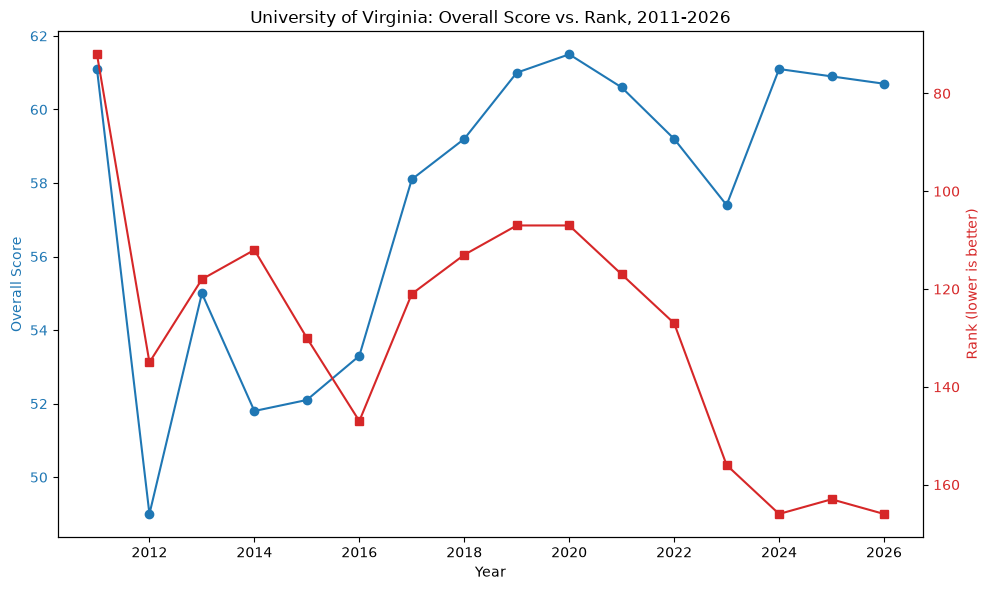

In [12]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(uva['year'], uva['scores_overall'], color='tab:blue', marker='o', label='Overall Score')
ax1.set_xlabel('Year')
ax1.set_ylabel('Overall Score', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(uva['year'], uva['rank'], color='tab:red', marker='s', label='Rank')
ax2.set_ylabel('Rank (lower is better)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.invert_yaxis()

plt.title('University of Virginia: Overall Score vs. Rank, 2011-2026')
fig.tight_layout()
plt.show()

**Observation:** UVA's overall score has stayed roughly flat (low-to-mid 60s) since ~2017, but its rank has steadily worsened. This is the central puzzle: a stable score is producing a falling rank, implying the *competitive bar* is rising around UVA.

## 2. Sub-score Trends for UVA

Breaking down the overall score into its component pillars.

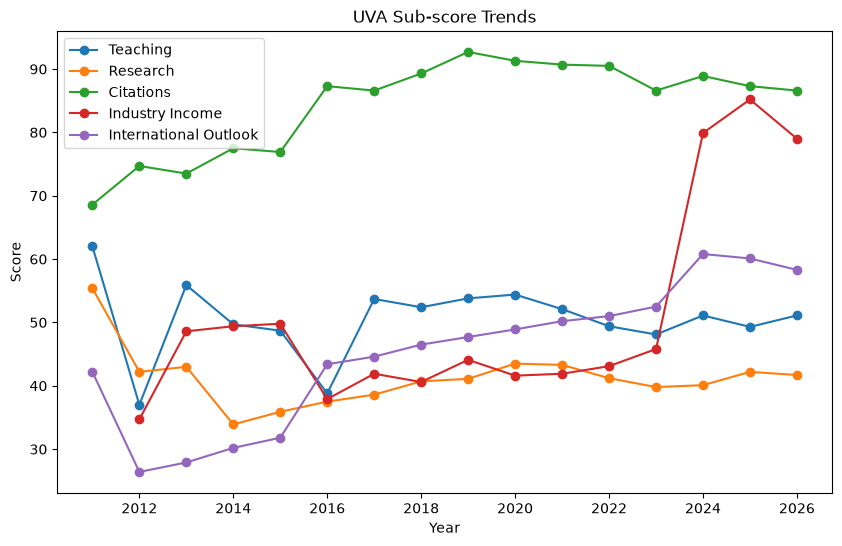

In [13]:
fig, ax = plt.subplots(figsize=(10,6))
for col, label in [
    ('scores_teaching', 'Teaching'),
    ('scores_research', 'Research'),
    ('scores_citations', 'Citations'),
    ('scores_industry_income', 'Industry Income'),
    ('scores_international_outlook', 'International Outlook'),
]:
    ax.plot(uva['year'], uva[col], marker='o', label=label)

ax.set_xlabel('Year')
ax.set_ylabel('Score')
ax.set_title('UVA Sub-score Trends')
ax.legend()
plt.show()

**Observation:** Teaching and research have eroded modestly since ~2020, while industry income and international outlook have risen substantially -- largely offsetting each other in the overall score.

## 3. Benchmarking Against Public AAU Peers (2020 vs 2026)

In [14]:
recent = df[df['year'].isin([2020, 2026])]
aau = recent[recent['public_aau_flag'] == 1]

piv = aau.pivot_table(index='name', columns='year', values=['rank','scores_overall'], aggfunc='first')
piv.columns = [f'{a}_{b}' for a, b in piv.columns]
piv = piv.dropna(subset=['rank_2020', 'rank_2026'])

piv['rank_change'] = piv['rank_2020'] - piv['rank_2026']   # positive = improved
piv['score_change'] = piv['scores_overall_2026'] - piv['scores_overall_2020']
piv = piv.sort_values('rank_change')

piv[['rank_2020','rank_2026','rank_change','scores_overall_2020','scores_overall_2026','score_change']]

,rank_2020,rank_2026,rank_change,scores_overall_2020,scores_overall_2026,score_change
name,,,,,,
Indiana University,134.0,198.0,-64.0,58.4,58.8,0.4
University of Virginia,107.0,166.0,-59.0,61.5,60.7,-0.8
University of Pittsburgh-Pittsburgh campus,113.0,156.0,-43.0,60.4,61.4,1.0
Ohio State University,70.0,108.0,-38.0,66.1,65.4,-0.7
University of Colorado Boulder,124.0,159.0,-35.0,59.6,61.3,1.7
University of Arizona,104.0,138.0,-34.0,61.8,62.6,0.8
Penn State,78.0,108.0,-30.0,64.2,65.4,1.2
"University of Maryland, College Park",91.0,116.0,-25.0,62.7,65.0,2.3
University of North Carolina at Chapel Hill,54.0,78.0,-24.0,69.9,70.3,0.4


In [15]:
print('Mean score change across Public AAU peers:', round(piv['score_change'].mean(), 2))
print('Mean rank change across Public AAU peers:', round(piv['rank_change'].mean(), 2))
print()
print('UVA score change:', round(piv.loc['University of Virginia','score_change'], 2))
print('UVA rank change:', round(piv.loc['University of Virginia','rank_change'], 2))

Mean score change across Public AAU peers: 2.44
Mean rank change across Public AAU peers: -13.41

UVA score change: -0.8
UVA rank change: -59.0


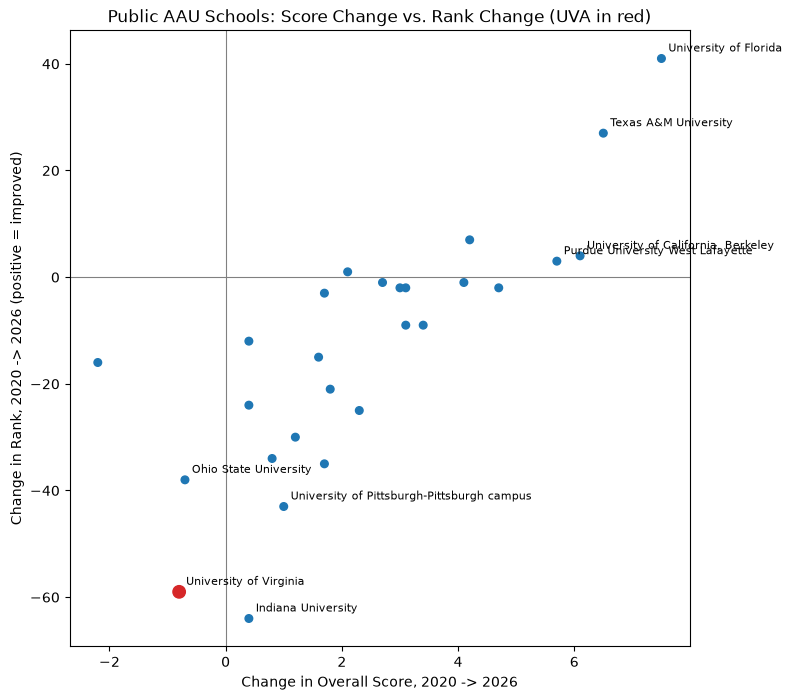

In [16]:
fig, ax = plt.subplots(figsize=(8,8))

colors = ['tab:red' if name == 'University of Virginia' else 'tab:blue' for name in piv.index]
sizes = [80 if name == 'University of Virginia' else 30 for name in piv.index]

ax.scatter(piv['score_change'], piv['rank_change'], c=colors, s=sizes)

for name, row in piv.iterrows():
    if name == 'University of Virginia' or abs(row['rank_change']) > 35 or abs(row['score_change']) > 5:
        ax.annotate(name, (row['score_change'], row['rank_change']), fontsize=8,
                     xytext=(5,5), textcoords='offset points')

ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Change in Overall Score, 2020 -> 2026')
ax.set_ylabel('Change in Rank, 2020 -> 2026 (positive = improved)')
ax.set_title('Public AAU Schools: Score Change vs. Rank Change (UVA in red)')
plt.show()

**Observation:** Most Public AAU peers improved their score (mean +2.4 pts) and held or gained rank (mean +13 places). UVA is one of only five AAU publics whose score *fell* (-0.8), and it has the second-worst rank decline (-59 places) in the group, behind only Indiana University.

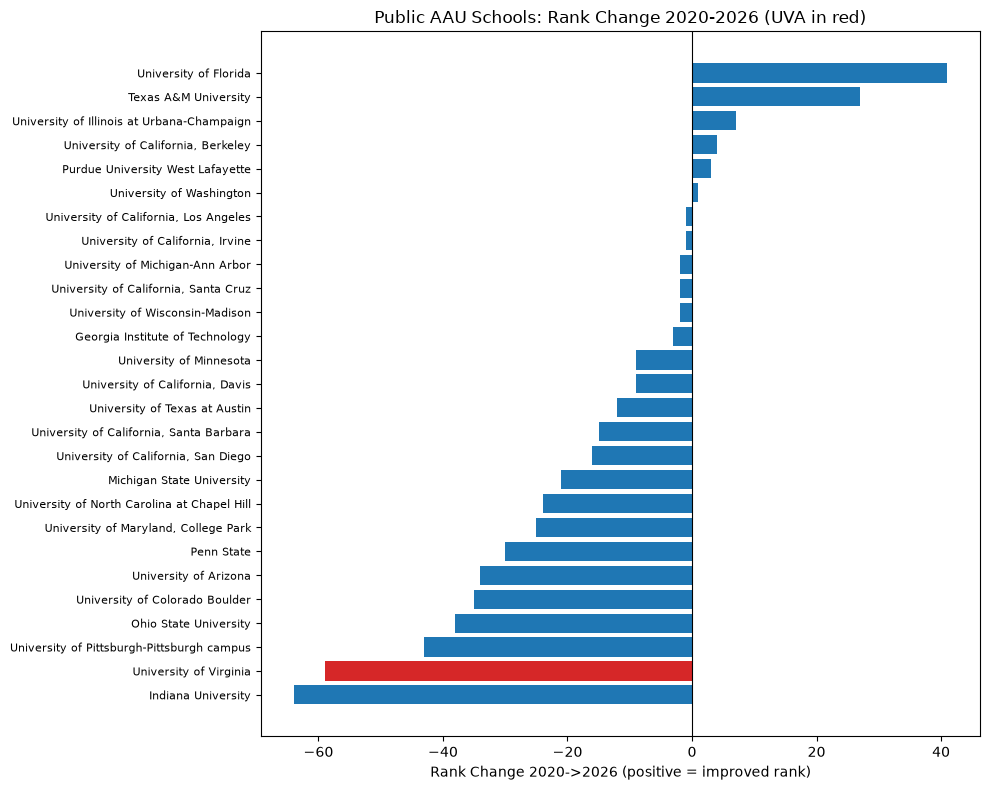

In [17]:
fig, ax = plt.subplots(figsize=(10,8))

y_pos = range(len(piv))
colors = ['tab:red' if name == 'University of Virginia' else 'tab:blue' for name in piv.index]

ax.barh(y_pos, piv['rank_change'], color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(piv.index, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Rank Change 2020->2026 (positive = improved rank)')
ax.set_title('Public AAU Schools: Rank Change 2020-2026 (UVA in red)')
plt.tight_layout()
plt.show()

## 4. The Rising Bar: How Many Schools Now Beat UVA's Score?

In [18]:
uva_2026_score = uva.loc[uva['year']==2026, 'scores_overall'].values[0]

counts = {}
for yr in [2020, 2026]:
    sub = df[df['year']==yr]
    counts[yr] = {
        'total_schools': sub.shape[0],
        'schools_above_uva_score': (sub['scores_overall'] > uva_2026_score).sum()
    }

counts_df = pd.DataFrame(counts).T
counts_df

,total_schools,schools_above_uva_score
2020,1397,112
2026,201,166


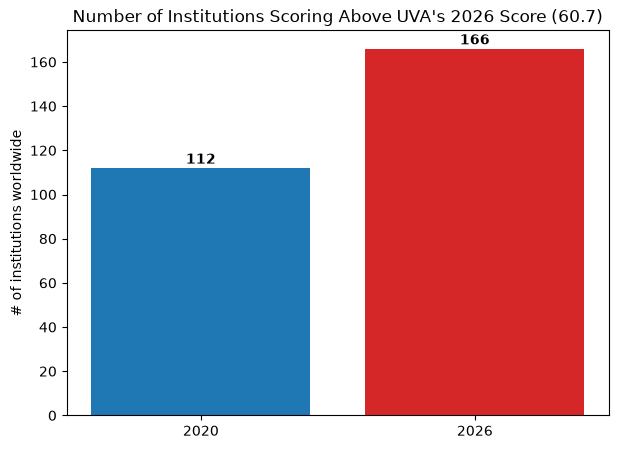

In [19]:
fig, ax = plt.subplots(figsize=(7,5))
ax.bar(['2020','2026'], counts_df['schools_above_uva_score'], color=['tab:blue','tab:red'])
ax.set_ylabel('# of institutions worldwide')
ax.set_title(f'Number of Institutions Scoring Above UVA\'s 2026 Score ({uva_2026_score})')
for i, v in enumerate(counts_df['schools_above_uva_score']):
    ax.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.show()

**Observation:** A score of ~60.7 placed roughly 112 institutions ahead of you in 2020. The same score now has ~166 institutions ahead of it -- a ~48% increase in the size of the field that 'beats' UVA's score. Standing still on score is functionally falling behind.

## 5. Global Country Trends: Top-200 Representation

In [20]:
top200_2020 = df[(df['year']==2020) & (df['rank']<=200)]['location'].value_counts().head(10)
top200_2026 = df[(df['year']==2026) & (df['rank']<=200)]['location'].value_counts().head(10)

country_compare = pd.DataFrame({'2020': top200_2020, '2026': top200_2026}).fillna(0)
country_compare = country_compare.sort_values('2020', ascending=False)
country_compare

,2020,2026
location,,
United States,60,55
United Kingdom,28,26
Germany,23,17
Australia,11,10
Netherlands,11,11
Canada,7,9
Switzerland,7,6
China,7,13
South Korea,6,6


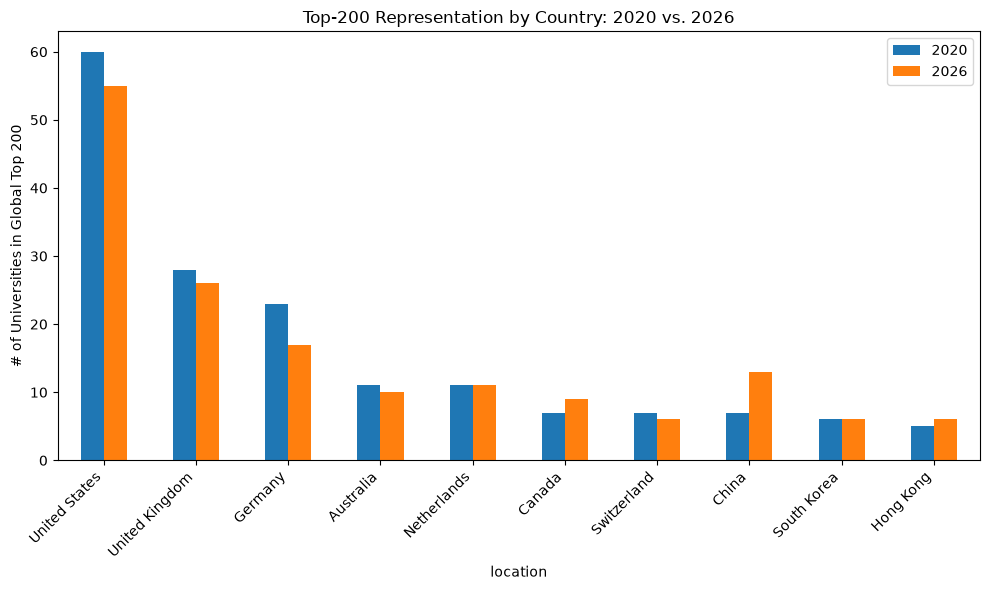

In [21]:
fig, ax = plt.subplots(figsize=(10,6))
country_compare.plot(kind='bar', ax=ax)
ax.set_ylabel('# of Universities in Global Top 200')
ax.set_title('Top-200 Representation by Country: 2020 vs. 2026')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observation:** The US, UK, Germany, and Australia have all *lost* top-200 slots, while China nearly doubled its representation (7 -> 13).

## 6. China's Rapid Score Gains (2020 -> 2026)

In [22]:
china = df[(df['location']=='China') & (df['year'].isin([2020,2026]))]
cpiv = china.pivot_table(index='name', columns='year', values=['rank','scores_overall'], aggfunc='first')
cpiv.columns = [f'{a}_{b}' for a, b in cpiv.columns]
cpiv = cpiv.dropna(subset=['rank_2020','rank_2026'])
cpiv['score_change'] = cpiv['scores_overall_2026'] - cpiv['scores_overall_2020']
cpiv = cpiv.sort_values('score_change', ascending=False)

cpiv[['rank_2020','rank_2026','scores_overall_2020','scores_overall_2026','score_change']].head(10)

,rank_2020,rank_2026,scores_overall_2020,scores_overall_2026,score_change
name,,,,,
Shanghai Jiao Tong University,157.0,40.0,56.9,77.6,20.7
Fudan University,109.0,36.0,61.4,79.3,17.9
Zhejiang University,107.0,39.0,61.5,78.3,16.8
Nanjing University,144.0,62.0,57.6,73.7,16.1
University of Science and Technology of China,80.0,51.0,64.0,75.7,11.7
Tsinghua University,23.0,12.0,82.6,93.0,10.4
Peking University,24.0,13.0,82.3,92.3,10.0


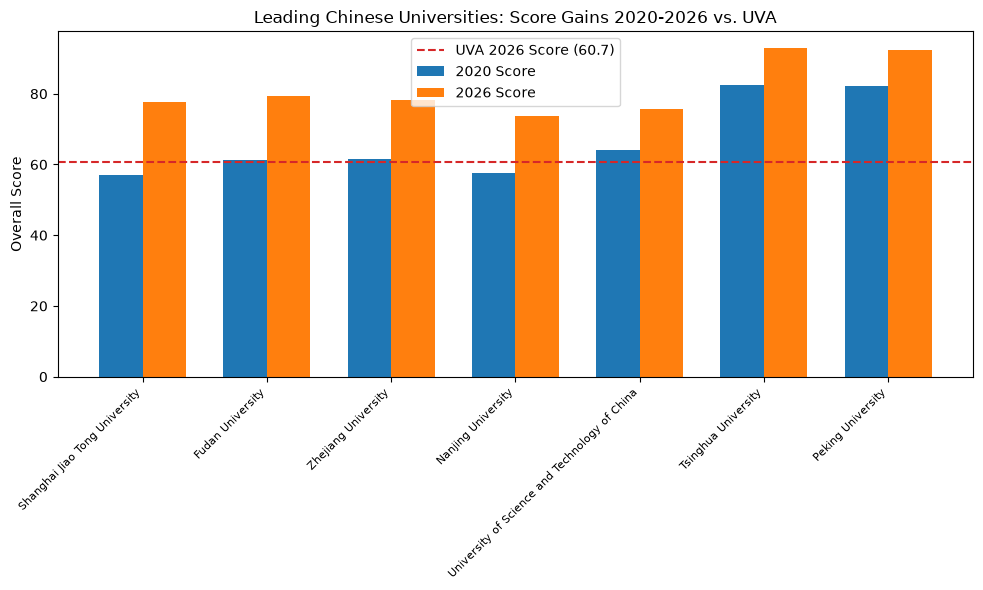

In [23]:
top_china = cpiv.head(7)

fig, ax = plt.subplots(figsize=(10,6))
x = range(len(top_china))
width = 0.35

ax.bar([i - width/2 for i in x], top_china['scores_overall_2020'], width, label='2020 Score')
ax.bar([i + width/2 for i in x], top_china['scores_overall_2026'], width, label='2026 Score')

# UVA reference line
ax.axhline(uva_2026_score, color='tab:red', linestyle='--', label=f'UVA 2026 Score ({uva_2026_score})')

ax.set_xticks(x)
ax.set_xticklabels(top_china.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Overall Score')
ax.set_title('Leading Chinese Universities: Score Gains 2020-2026 vs. UVA')
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** Schools like Shanghai Jiao Tong (+20.7), Fudan (+17.9), and Zhejiang (+16.8) have gained massively, several moving from below UVA's level to well above it. This rapid improvement among Chinese research universities is a major driver of the rising competitive bar.

## 7. Hong Kong Universities: Score and Rank Trends

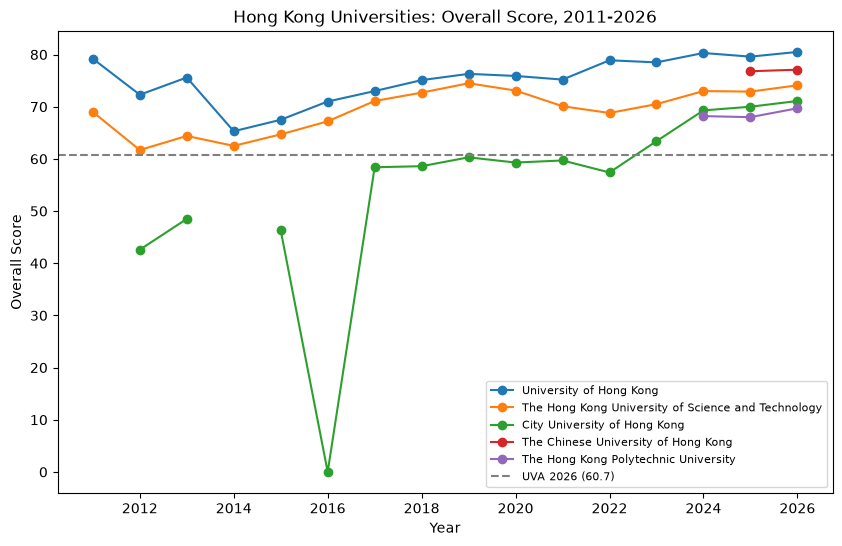

In [24]:
hk_schools = ['University of Hong Kong','The Hong Kong University of Science and Technology',
               'City University of Hong Kong','The Chinese University of Hong Kong',
               'The Hong Kong Polytechnic University']

fig, ax = plt.subplots(figsize=(10,6))
for name in hk_schools:
    sub = df[df['name']==name].sort_values('year')
    ax.plot(sub['year'], sub['scores_overall'], marker='o', label=name)

ax.axhline(uva_2026_score, color='gray', linestyle='--', label=f'UVA 2026 ({uva_2026_score})')
ax.set_xlabel('Year')
ax.set_ylabel('Overall Score')
ax.set_title('Hong Kong Universities: Overall Score, 2011-2026')
ax.legend(fontsize=8)
plt.show()

In [25]:
hk = df[(df['location']=='Hong Kong') & (df['year'].isin([2020,2026]))]
hkpiv = hk.pivot_table(index='name', columns='year', values=['rank','scores_overall'], aggfunc='first')
hkpiv.columns = [f'{a}_{b}' for a, b in hkpiv.columns]
hkpiv = hkpiv.dropna(subset=['rank_2020','rank_2026'])
hkpiv['rank_change'] = hkpiv['rank_2020'] - hkpiv['rank_2026']
hkpiv['score_change'] = hkpiv['scores_overall_2026'] - hkpiv['scores_overall_2020']
hkpiv = hkpiv.sort_values('score_change', ascending=False)
hkpiv[['rank_2020','rank_2026','rank_change','scores_overall_2020','scores_overall_2026','score_change']]

,rank_2020,rank_2026,rank_change,scores_overall_2020,scores_overall_2026,score_change
name,,,,,,
City University of Hong Kong,126.0,73.0,53.0,59.3,71.1,11.8
University of Hong Kong,35.0,33.0,2.0,75.9,80.5,4.6
The Hong Kong University of Science and Technology,47.0,58.0,-11.0,73.1,74.1,1.0


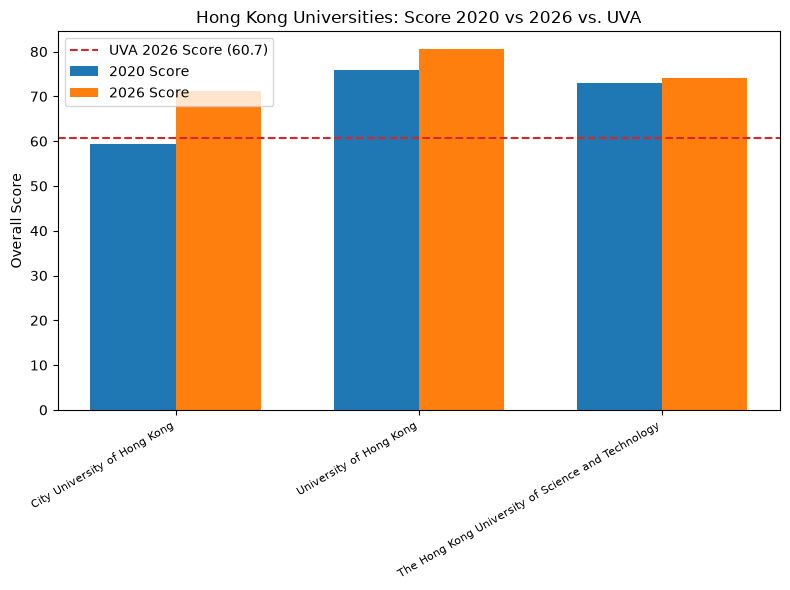

In [26]:
fig, ax = plt.subplots(figsize=(8,6))
x = range(len(hkpiv))
width = 0.35

ax.bar([i - width/2 for i in x], hkpiv['scores_overall_2020'], width, label='2020 Score')
ax.bar([i + width/2 for i in x], hkpiv['scores_overall_2026'], width, label='2026 Score')
ax.axhline(uva_2026_score, color='tab:red', linestyle='--', label=f'UVA 2026 Score ({uva_2026_score})')

ax.set_xticks(x)
ax.set_xticklabels(hkpiv.index, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Overall Score')
ax.set_title('Hong Kong Universities: Score 2020 vs 2026 vs. UVA')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
for yr in [2020, 2026]:
    n = ((df['year']==yr) & (df['rank']<=200) & (df['location']=='Hong Kong')).sum()
    print(f'Hong Kong universities in global Top 200 ({yr}): {n}')

Hong Kong universities in global Top 200 (2020): 5
Hong Kong universities in global Top 200 (2026): 6


**Observations:**
- **University of Hong Kong** (the territory's flagship) has steadily strengthened: score rose from 75.9 (2020) to 80.5 (2026), and rank improved slightly (35 -> 33). It sits comfortably above UVA's level.
- **City University of Hong Kong** is the standout riser: score jumped from 59.3 to 71.1 (+11.8), and rank improved dramatically from 126 to 73 (+53 places) -- a trajectory similar to the fast-improving Chinese mainland schools.
- **Hong Kong University of Science and Technology** dipped mid-decade (rank fell into the 60s) but has recovered, ending essentially flat to slightly up (73.1 -> 74.1), though its rank slipped (47 -> 58) due to the rising bar -- the same dynamic affecting UVA.
- **Chinese University of Hong Kong** and **Hong Kong Polytechnic University** are newer entrants to these score bands (data starts 2025), both already scoring above UVA's level (76-77 and ~68-70 respectively) and improving year over year.
- Hong Kong's overall Top-200 presence held steady to slightly up (5 -> 6 institutions).

**Takeaway:** Like mainland China, Hong Kong institutions are broadly improving or holding strong positions well above UVA's score level. Even HKUST, which experienced a rank decline similar in *cause* to UVA's (flat-to-slightly-up score against a rising bar), still scores meaningfully higher than UVA. This reinforces that the global baseline -- not just mainland China -- has risen across the broader Greater China region.

## 8. UVA Sub-score Distribution vs. Public AAU Peers (2026)

For each of the five THE scoring pillars, the distribution across all 27 Public AAU schools is shown as a box plot with individual dots. UVA is highlighted in red.

C:\Users\tgsch\AppData\Local\Temp\ipykernel_16096\329743836.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(vals, vert=True, patch_artist=True, widths=0.4,
C:\Users\tgsch\AppData\Local\Temp\ipykernel_16096\329743836.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(vals, vert=True, patch_artist=True, widths=0.4,
C:\Users\tgsch\AppData\Local\Temp\ipykernel_16096\329743836.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(vals, vert=True, patch_artist=True, widths=0.4,
C:\Users\tgsch\AppData\Local\Temp\ipykernel_16096\329743836.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matp

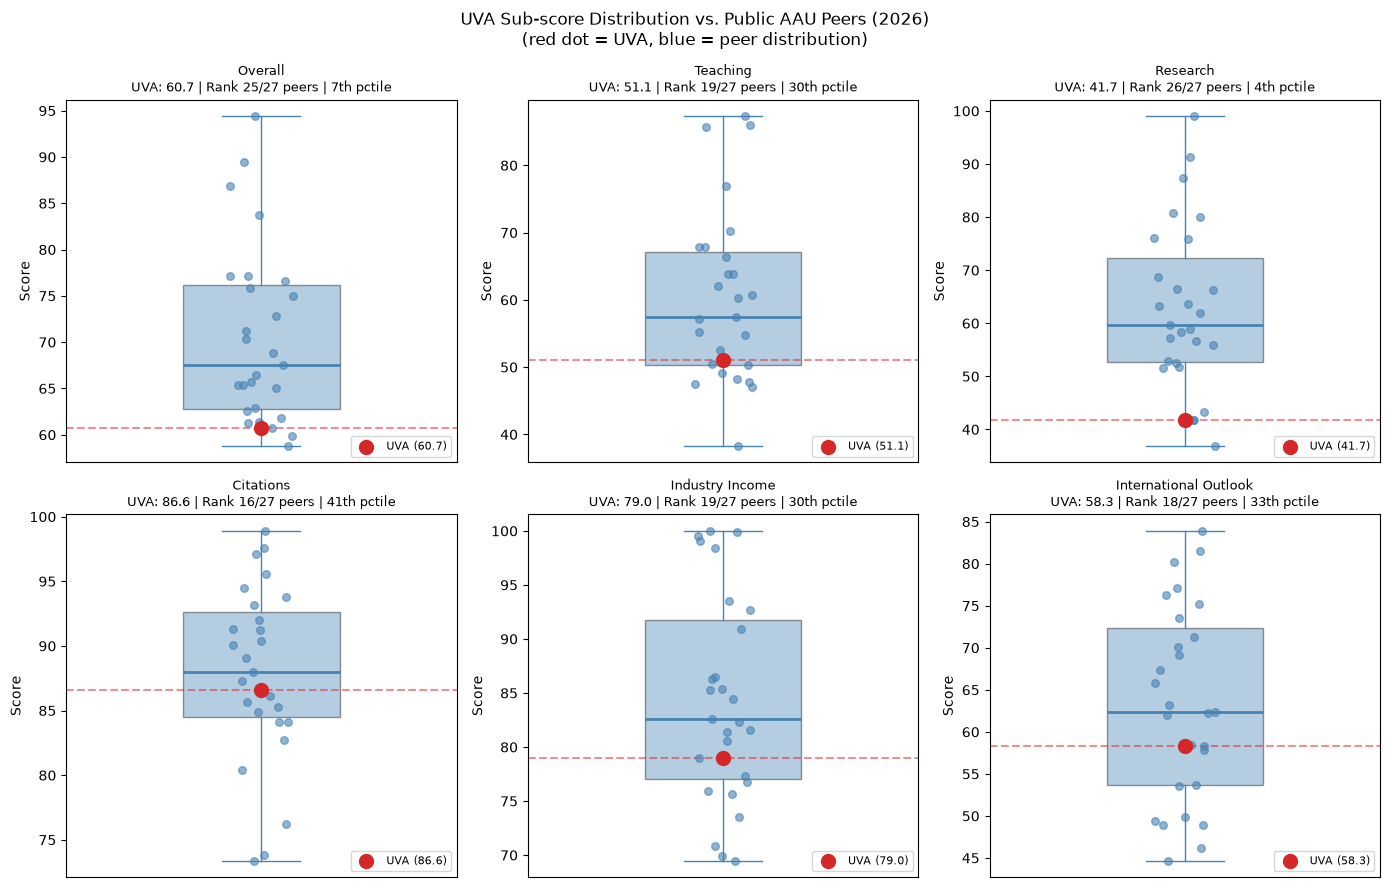

In [28]:
import numpy as np

aau_2026 = df[(df['public_aau_flag']==1) & (df['year']==2026)].copy()
uva_2026 = aau_2026[aau_2026['name']=='University of Virginia'].iloc[0]

pillars = [
    ('scores_overall',              'Overall'),
    ('scores_teaching',             'Teaching'),
    ('scores_research',             'Research'),
    ('scores_citations',            'Citations'),
    ('scores_industry_income',      'Industry Income'),
    ('scores_international_outlook','International Outlook'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, pillars):
    vals = aau_2026[col].dropna().values
    uva_val = uva_2026[col]

    # box plot
    bp = ax.boxplot(vals, vert=True, patch_artist=True, widths=0.4,
                    boxprops=dict(facecolor='steelblue', alpha=0.4),
                    medianprops=dict(color='steelblue', linewidth=2),
                    whiskerprops=dict(color='steelblue'),
                    capprops=dict(color='steelblue'),
                    flierprops=dict(marker=''))

    # jittered dots for all peers
    jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(1 + jitter, vals, color='steelblue', alpha=0.6, zorder=3, s=30)

    # UVA dot
    ax.scatter(1, uva_val, color='tab:red', zorder=5, s=100, label=f'UVA ({uva_val})')
    ax.axhline(uva_val, color='tab:red', linestyle='--', alpha=0.5)

    # percentile rank
    pct = (vals < uva_val).sum() / len(vals) * 100
    rank_n = int((vals >= uva_val).sum())

    ax.set_title(f'{label}\nUVA: {uva_val} | Rank {rank_n}/{len(vals)} peers | {pct:.0f}th pctile', fontsize=9)
    ax.set_xticks([])
    ax.set_ylabel('Score')
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('UVA Sub-score Distribution vs. Public AAU Peers (2026)\n(red dot = UVA, blue = peer distribution)', fontsize=12)
plt.tight_layout()
plt.show()

In [29]:
# Summary table: UVA score, peer median, peer rank, percentile
rows = []
for col, label in pillars:
    vals = aau_2026[col].dropna().values
    uva_val = uva_2026[col]
    rows.append({
        'Pillar': label,
        'UVA Score': uva_val,
        'Peer Median': round(float(np.median(vals)), 1),
        'Peer Min': round(float(vals.min()), 1),
        'Peer Max': round(float(vals.max()), 1),
        'UVA Rank (of 27)': int((vals >= uva_val).sum()),
        'UVA Percentile': f'{(vals < uva_val).sum() / len(vals) * 100:.0f}th'
    })

pd.DataFrame(rows).set_index('Pillar')

,UVA Score,Peer Median,Peer Min,Peer Max,UVA Rank (of 27),UVA Percentile
Pillar,,,,,,
Overall,60.7,67.5,58.8,94.4,25,7th
Teaching,51.1,57.4,38.3,87.3,19,30th
Research,41.7,59.6,36.9,99.0,26,4th
Citations,86.6,88.0,73.4,98.9,16,41th
Industry Income,79.0,82.6,69.5,100.0,19,30th
International Outlook,58.3,62.4,44.7,83.9,18,33th


**Observations:**
- **Overall**: UVA sits near the bottom quartile of AAU peers, ranked 25th of 27. Only UCSC and Indiana trail it.
- **Teaching**: Below median (peer median ~60), ranked ~21st. Several peers score substantially higher.
- **Research**: UVA's weakest pillar relative to peers -- ranked near the bottom, tied with UCSC. Strong research output is the main differentiator for top-ranked AAU publics.
- **Citations**: A strength -- UVA ranks in the top half of peers here (~12th), benefiting from high-impact publication output relative to its research volume. Citations was updated in 2024 to be weighted less, contributing to the decline in overall score
- **Industry Income**: Solidly mid-pack, ranking ~14th. High variance in this pillar (range: 44-100) makes it volatile.
- **International Outlook**: Middle of the pack (~15th). Room to grow given UVA's strong brand, but not a differentiator.

UVA's rankings problem is mostly in Research, where it sits near the bottom of AAU peers despite a decent Citations score -- suggesting high-impact work but insufficient volume/investment. Improving the research pillar would have the largest multiplier effect on both research and citations scores.

## 9. Summary: Why is UVA's Rank Falling?

1. **UVA's overall score has been essentially flat** (61.5 in 2020 -> 60.7 in 2026, a decline of just 0.8 points), yet its rank fell from 107 to 166 -- a drop of 59 places.
2. **The competitive bar has risen sharply.** The number of institutions worldwide scoring above UVA's current level grew from ~112 (2020) to ~166 (2026), roughly a 48% increase.
3. **Public AAU peers are mostly improving while UVA stagnates.** Average peer score change was +2.4 pts (vs. UVA's -0.8), and average peer rank change was +13 places (vs. UVA's -59). UVA is one of only five AAU publics to lose score, and has the second-worst rank decline in the group.
4. **International competition from Asia is a major driver.** Chinese universities posted large score gains (Shanghai Jiao Tong +20.7, Fudan +17.9, Zhejiang +16.8, Tsinghua +10.4, Peking +10.0), and China's top-200 representation nearly doubled (7 -> 13) while the US, UK, Germany, and Australia all lost top-200 slots.
5. **Within UVA's sub-scores**, modest declines in teaching and research have been offset by large gains in industry income and international outlook

**Bottom line:** UVA's ranking decline is due to low score growth at a time when most peers are improving rapidly, raising the bar for every fixed rank position.